
# Clustering gravitacional clásico de Wright (1977) sobre Iris en dos variables

Este notebook presenta una implementación del **clustering gravitacional clásico** en la línea del artículo de **W. E. Wright (1977)**. El análisis se restringe a la variante **Markoviana de atracción unitaria**, que es la formulación que el propio artículo destaca como especialmente adecuada para fines de clustering.

El flujo experimental se organiza de acuerdo con esa lectura:

1. cada observación se interpreta como una partícula en un espacio euclidiano;
2. las partículas se desplazan por atracción mutua;
3. cuando dos partículas quedan suficientemente próximas, se fusionan en su centroide ponderado;
4. la jerarquía se interpreta a partir de los **tiempos de fusión** y de la **vida temporal** de cada nivel \(k\).

El conjunto de datos es **Iris**, usando solo dos variables:

- longitud del pétalo,
- ancho del pétalo.

Además de la lectura principal fiel a Wright, se incorporan dos apoyos analíticos complementarios:

- la métrica de **silhouette**;
- un **dendrograma** construido a partir de los tiempos de fusión, como representación moderna compatible con el *tree plot* del artículo.

El notebook conserva dos referencias botánicas distintas:

- la referencia de las **tres especies** originales;
- la lectura específica de **_Iris setosa_ frente al resto**, ya que en esta proyección bidimensional esa separación suele aparecer con gran claridad.



## 1. Marco teórico según Wright (1977)

La idea central del artículo es reemplazar una regla puramente discreta de aglomeración por un **proceso dinámico continuo aproximado**. En lugar de decidir uniones solo a partir de una distancia mínima instantánea, el sistema evoluciona en el tiempo y las fusiones aparecen como consecuencia de esa dinámica.

En el modelo formal:

- inicialmente hay \(n\) partículas;
- cada partícula tiene una localización \(s_i \in \mathbb{R}^m\) y una masa \(m_i\);
- la simulación se ejecuta mediante incrementos temporales pequeños;
- si dos partículas quedan a una distancia menor que un umbral \(\varepsilon\), se fusionan.

La actualización general de posiciones se expresa mediante una función gravitacional \(g(i,t,\Delta t)\), de modo que

$$
s_i(t+\Delta t)=s_i(t)+g(i,t,\Delta t).
$$

Wright distingue entre varias posibilidades. En este notebook se usa la **variante Markoviana de atracción unitaria**, porque elimina el término de velocidad y hace que la interacción dependa solo del estado presente del sistema. En esa versión, el desplazamiento base de la partícula \(i\) viene dado por una suma de términos de la forma

$$
\sum_{j \neq i}\frac{s_j-s_i}{\lVert s_j-s_i\rVert^3}.
$$

La interpretación geométrica es clara:

- partículas cercanas ejercen una influencia mucho mayor que partículas lejanas;
- la atracción no depende de que un grupo ya sea grande, sino de la separación espacial;
- grupos compactos tienden a consolidarse pronto y a mantenerse estables antes de una fusión de mayor escala.

Ese último punto es importante en la lectura de Wright: la fortaleza de una partición no se juzga primero por una métrica externa, sino por el tiempo durante el cual el sistema permanece con un número fijo de partículas activas.

Si un nivel \(k\) permanece mucho tiempo, entonces la partición asociada a ese nivel se interpreta como particularmente estable.


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25



## 2. Datos y problema experimental

Se trabaja con el conjunto **Iris** y con dos variables del pétalo. La elección no es arbitraria: en esta proyección la especie **_Iris setosa_** suele aparecer claramente separada, mientras que **_Iris versicolor_** y **_Iris virginica_** conservan una zona de mayor solapamiento.

Esto permite estudiar simultáneamente dos lecturas:

1. la referencia completa de las **tres especies**;
2. la separación fuerte **setosa vs. resto**, que en el espíritu del paper puede emerger como un nivel de vida temporal alta.

Siguiendo la observación metodológica de Wright, las variables se escalan antes de la simulación para que las magnitudes sean comparables en el espacio euclidiano.


In [2]:

iris = load_iris(as_frame=True)

feature_cols = ["petal length (cm)", "petal width (cm)"]
X_raw = iris.frame[feature_cols].to_numpy()
y3 = iris.target.to_numpy()
species_names = iris.target_names
species_text = species_names[y3]
y_bin = (y3 == 0).astype(int)  # 1 = setosa, 0 = no setosa

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

df_view = pd.DataFrame(X_raw, columns=feature_cols)
df_view["species"] = species_text

print("Forma del conjunto:", X.shape)
print("Variables usadas:", feature_cols)
print("Especies:", list(species_names))
df_view.head()


Forma del conjunto: (150, 2)
Variables usadas: ['petal length (cm)', 'petal width (cm)']
Especies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,petal length (cm),petal width (cm),species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


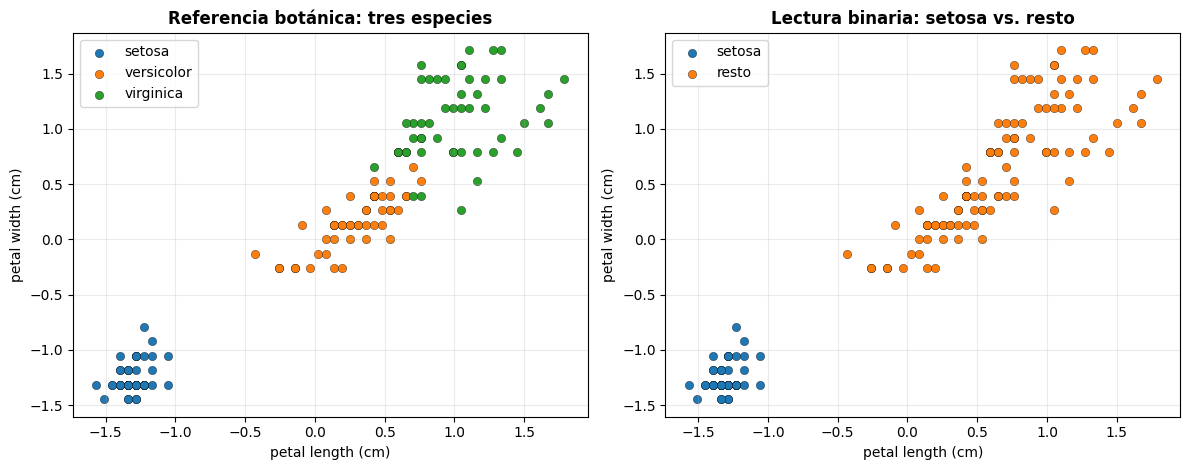

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for k, name in enumerate(species_names):
    mask = y3 == k
    axes[0].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=name
    )
axes[0].set_title("Referencia botánica: tres especies", fontweight="bold")
axes[0].set_xlabel(feature_cols[0])
axes[0].set_ylabel(feature_cols[1])
axes[0].legend()

labels_bin = np.where(y_bin == 1, "setosa", "resto")
for label in ["setosa", "resto"]:
    mask = labels_bin == label
    axes[1].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=label
    )
axes[1].set_title("Lectura binaria: setosa vs. resto", fontweight="bold")
axes[1].set_xlabel(feature_cols[0])
axes[1].set_ylabel(feature_cols[1])
axes[1].legend()

plt.tight_layout()
plt.show()



## 3. Implementación clásica alineada con Wright

La clase siguiente implementa la variante clásica que se venía usando en la última versión del notebook, ajustada a la formulación de Wright que interesa aquí. Los elementos retenidos son:

- paso adaptativo controlado por \(\delta\);
- fusión por proximidad con \(\varepsilon \approx 2\delta\);
- reemplazo por centroide ponderado al fusionar;
- registro explícito del tiempo de cada fusión;
- cálculo de la **vida temporal** de cada nivel \(k\).

La estructura resultante permite recuperar:

- el **nivel más fuerte** según Wright;
- la partición correspondiente a un valor particular de \(k\), por ejemplo \(k=3\);
- una matriz de enlace para visualizar la jerarquía como dendrograma.


In [4]:

class Wright1977ClassicalClustering:
    """
    Implementación de la variante Markoviana de atracción unitaria
    inspirada en Wright (1977).
    """

    def __init__(self, delta=0.03, epsilon=None, max_iter=4000, G=1.0):
        self.delta = float(delta)
        self.epsilon = float(2 * delta if epsilon is None else epsilon)
        self.max_iter = int(max_iter)
        self.G = float(G)

    @staticmethod
    def _partition_to_labels(partition, n):
        labels = np.full(n, -1, dtype=int)
        for cid, cluster in enumerate(partition):
            for idx in cluster:
                labels[idx] = cid
        return labels

    @staticmethod
    def _copy_partition(active, membership):
        return [sorted(membership[i]) for i in np.where(active)[0] if membership[i]]

    def _displacement_base(self, pos):
        n = len(pos)
        diff = pos[np.newaxis, :, :] - pos[:, np.newaxis, :]
        dist_sq = np.sum(diff ** 2, axis=2)

        mask = ~np.eye(n, dtype=bool)
        dist_sq_safe = np.where(mask, np.maximum(dist_sq, 1e-15), 1.0)
        dist = np.sqrt(dist_sq_safe)

        direction = np.where(mask[:, :, np.newaxis], diff / dist[:, :, np.newaxis], 0.0)
        coeff = np.where(mask, 1.0 / dist_sq_safe, 0.0)

        return (coeff[:, :, np.newaxis] * direction).sum(axis=1)

    def fit(self, X, masses=None):
        X = np.asarray(X, dtype=float)
        n, _ = X.shape

        pos = X.copy()
        masses = np.ones(n, dtype=float) if masses is None else np.asarray(masses, dtype=float).copy()

        active = np.ones(n, dtype=bool)
        membership = [[i] for i in range(n)]

        cluster_node_id = {i: i for i in range(n)}
        cluster_size = {i: 1 for i in range(n)}
        next_node_id = n
        linkage_rows = []

        t = 0.0
        merge_log = []
        history_positions = [pos.copy()]
        history_times = [0.0]
        history_n = [n]
        history_mean_move = []

        for _ in range(self.max_iter):
            active_idx = np.where(active)[0]
            if len(active_idx) <= 1:
                break

            pos_act = pos[active_idx]
            base = self._displacement_base(pos_act)
            max_norm = np.linalg.norm(base, axis=1).max()

            if (not np.isfinite(max_norm)) or (max_norm <= 1e-14):
                break

            dt = math.sqrt(self.delta / max_norm)
            move = self.G * (dt ** 2) * base
            pos[active_idx] = pos_act + move

            t += dt
            history_mean_move.append(float(np.linalg.norm(move, axis=1).mean()))

            while True:
                active_idx = np.where(active)[0]
                if len(active_idx) <= 1:
                    break

                pos_act = pos[active_idx]
                dists = np.linalg.norm(
                    pos_act[:, np.newaxis, :] - pos_act[np.newaxis, :, :],
                    axis=2,
                )
                np.fill_diagonal(dists, np.inf)

                min_dist = dists.min()
                if min_dist >= self.epsilon:
                    break

                i_local, j_local = np.unravel_index(np.argmin(dists), dists.shape)
                if i_local > j_local:
                    i_local, j_local = j_local, i_local

                i_global = active_idx[i_local]
                j_global = active_idx[j_local]

                mi, mj = masses[i_global], masses[j_global]
                m_tot = mi + mj

                pos[i_global] = (mi * pos[i_global] + mj * pos[j_global]) / m_tot
                masses[i_global] = m_tot
                masses[j_global] = 0.0

                membership[i_global].extend(membership[j_global])
                membership[j_global] = []
                active[j_global] = False

                left_id = cluster_node_id[i_global]
                right_id = cluster_node_id[j_global]
                new_id = next_node_id
                next_node_id += 1

                new_count = cluster_size[left_id] + cluster_size[right_id]
                linkage_rows.append([left_id, right_id, t, new_count])

                cluster_node_id[i_global] = new_id
                cluster_size[new_id] = new_count

                merge_log.append(
                    {
                        "time": float(t),
                        "n_clusters_after": int(active.sum()),
                        "partition_after": self._copy_partition(active, membership),
                        "merged_left": int(left_id),
                        "merged_right": int(right_id),
                        "merged_size": int(new_count),
                    }
                )

            history_positions.append(pos.copy())
            history_times.append(float(t))
            history_n.append(int(active.sum()))

            if active.sum() <= 1:
                break

        level_intervals = []
        prev_time = 0.0
        prev_k = n
        prev_partition = [[i] for i in range(n)]

        for event in merge_log:
            level_intervals.append(
                {
                    "k": prev_k,
                    "start": prev_time,
                    "end": event["time"],
                    "lifetime": event["time"] - prev_time,
                    "partition": prev_partition,
                }
            )
            prev_time = event["time"]
            prev_k = event["n_clusters_after"]
            prev_partition = [cluster.copy() for cluster in event["partition_after"]]

        self.history_ = {
            "positions": history_positions,
            "times": history_times,
            "n_particles": history_n,
            "mean_move": history_mean_move,
        }
        self.merge_log_ = pd.DataFrame(merge_log)
        self.level_intervals_ = pd.DataFrame(level_intervals)
        self.total_time_ = float(t)
        self.final_positions_ = pos.copy()
        self.linkage_matrix_ = np.asarray(linkage_rows, dtype=float) if linkage_rows else np.empty((0, 4))

        if len(self.level_intervals_) > 0:
            strongest = (
                self.level_intervals_[self.level_intervals_["k"] > 1]
                .sort_values(["lifetime", "k"], ascending=[False, True])
                .iloc[0]
            )
            self.strongest_k_ = int(strongest["k"])
            self.strongest_partition_ = strongest["partition"]
            self.strongest_lifetime_ = float(strongest["lifetime"])
            self.strongest_labels_ = self._partition_to_labels(self.strongest_partition_, n)
        else:
            self.strongest_k_ = int(active.sum())
            self.strongest_partition_ = self._copy_partition(active, membership)
            self.strongest_lifetime_ = 0.0
            self.strongest_labels_ = self._partition_to_labels(self.strongest_partition_, n)

        self.labels_ = self.strongest_labels_.copy()
        self.n_clusters_ = self.strongest_k_
        return self

    def labels_at_k(self, k):
        if len(self.level_intervals_) == 0:
            raise ValueError("No se registraron fusiones; no existe jerarquía temporal.")

        sub = self.level_intervals_[self.level_intervals_["k"] == k]
        if len(sub) == 0:
            raise ValueError(f"No se observó un nivel k={k} en la simulación.")

        best_row = sub.sort_values("lifetime", ascending=False).iloc[0]
        labels = self._partition_to_labels(best_row["partition"], len(self.strongest_labels_))
        return labels, float(best_row["lifetime"])



## 4. Selección de \(\delta\) y ajuste del modelo

En Wright, \(\delta\) cumple el papel de parámetro de aproximación numérica: debe ser lo suficientemente pequeño para que la simulación represente bien la dinámica, pero no tan pequeño que vuelva el procedimiento innecesariamente costoso.

Aquí se examina una malla breve de valores de \(\delta\). La interpretación principal sigue siendo la del paper: observar

- cuál es el **nivel más fuerte**;
- qué fracción del tiempo total representa;
- y cuál es el comportamiento de la partición en \(k=3\), dado que Iris tiene tres especies botánicas.

La métrica de **silhouette** se incluye solo como apoyo geométrico posterior a la simulación.


In [5]:

def safe_silhouette(X, labels):
    n_clusters = len(np.unique(labels))
    return silhouette_score(X, labels) if n_clusters > 1 else np.nan

rows = []
delta_grid = [0.01, 0.015, 0.02, 0.03, 0.05, 0.08]

for delta in delta_grid:
    model = Wright1977ClassicalClustering(delta=delta, epsilon=2 * delta, max_iter=4000)
    model.fit(X)

    strongest_labels = model.strongest_labels_
    strongest_k = model.strongest_k_
    strongest_sil = safe_silhouette(X, strongest_labels)
    ari_strong_3 = adjusted_rand_score(y3, strongest_labels)
    ari_strong_bin = adjusted_rand_score(y_bin, strongest_labels)

    row = {
        "delta": delta,
        "strongest_k": strongest_k,
        "strongest_lifetime": model.strongest_lifetime_,
        "total_time": model.total_time_,
        "life_pct": model.strongest_lifetime_ / model.total_time_ if model.total_time_ > 0 else np.nan,
        "silhouette_strongest": strongest_sil,
        "ARI_strongest_vs_3species": ari_strong_3,
        "ARI_strongest_vs_setosa_resto": ari_strong_bin,
    }

    try:
        labels_k3, life_k3 = model.labels_at_k(3)
        row["life_k3"] = life_k3
        row["silhouette_k3"] = safe_silhouette(X, labels_k3)
        row["ARI_k3_vs_3species"] = adjusted_rand_score(y3, labels_k3)
    except ValueError:
        row["life_k3"] = np.nan
        row["silhouette_k3"] = np.nan
        row["ARI_k3_vs_3species"] = np.nan

    rows.append(row)

delta_search = pd.DataFrame(rows).sort_values("delta").reset_index(drop=True)
delta_search.round(4)


,delta,strongest_k,strongest_lifetime,total_time,life_pct,silhouette_strongest,ARI_strongest_vs_3species,ARI_strongest_vs_setosa_resto,life_k3,silhouette_k3,ARI_k3_vs_3species
0,0.010,2,16.2121,22.9811,0.7055,0.7434,0.5681,1.0,1.8378,0.6099,0.6357
1,0.015,2,12.9093,18.8828,0.6837,0.7434,0.5681,1.0,2.8344,0.6099,0.6357
2,0.020,2,8.2708,13.4226,0.6162,0.7434,0.5681,1.0,2.0465,0.5893,0.7074
3,0.030,2,9.5682,13.3518,0.7166,0.7434,0.5681,1.0,1.6471,0.6099,0.6357
4,0.050,2,7.6773,10.6188,0.7230,0.7434,0.5681,1.0,1.4189,0.6099,0.6357
5,0.080,2,5.4900,7.4960,0.7324,0.7434,0.5681,1.0,1.0592,0.6496,0.9039



Para fijar un valor final de \(\delta\), se privilegia primero la lectura geométrica complementaria en \(k=3\), porque el conjunto tiene tres especies y aquí interesa examinar explícitamente ese comportamiento. En caso de empate, se selecciona el menor \(\delta\), lo cual mantiene una aproximación numérica más fina.

La interpretación de Wright no desaparece: una vez fijado \(\delta\), se reportan por separado

- el **nivel más fuerte** de la simulación;
- y la partición obtenida al **cortar en \(k=3\)**.


In [6]:

tol = 1e-12
valid_k3 = delta_search.dropna(subset=["silhouette_k3"]).copy()
best_sil_k3 = valid_k3["silhouette_k3"].max()
best_delta = float(valid_k3.loc[valid_k3["silhouette_k3"] >= best_sil_k3 - tol, "delta"].min())

classic = Wright1977ClassicalClustering(
    delta=best_delta,
    epsilon=2 * best_delta,
    max_iter=4000,
)
classic.fit(X)

strong_labels = classic.strongest_labels_
strong_k = classic.strongest_k_
strong_life = classic.strongest_lifetime_
strong_pct = strong_life / classic.total_time_ if classic.total_time_ > 0 else np.nan
strong_silhouette = safe_silhouette(X, strong_labels)
strong_ari_3 = adjusted_rand_score(y3, strong_labels)
strong_ari_bin = adjusted_rand_score(y_bin, strong_labels)

labels_k3, life_k3 = classic.labels_at_k(3)
sil_k3 = safe_silhouette(X, labels_k3)
ari_k3_3species = adjusted_rand_score(y3, labels_k3)
ari_k3_bin = adjusted_rand_score(y_bin, labels_k3)

summary = pd.DataFrame(
    [
        {
            "lectura": "nivel_mas_fuerte",
            "delta": best_delta,
            "k": strong_k,
            "lifetime": strong_life,
            "life_pct": strong_pct,
            "silhouette": strong_silhouette,
            "ARI_vs_3species": strong_ari_3,
            "ARI_vs_setosa_resto": strong_ari_bin,
        },
        {
            "lectura": "corte_en_k3",
            "delta": best_delta,
            "k": 3,
            "lifetime": life_k3,
            "life_pct": life_k3 / classic.total_time_ if classic.total_time_ > 0 else np.nan,
            "silhouette": sil_k3,
            "ARI_vs_3species": ari_k3_3species,
            "ARI_vs_setosa_resto": ari_k3_bin,
        },
    ]
)

summary.round(4)


,lectura,delta,k,lifetime,life_pct,silhouette,ARI_vs_3species,ARI_vs_setosa_resto
0,nivel_mas_fuerte,0.08,2,5.4900,0.7324,0.7434,0.5681,1.0000
1,corte_en_k3,0.08,3,1.0592,0.1413,0.6496,0.9039,0.5722



## 5. Lectura de resultados

Desde la lógica de Wright, la primera pregunta es: **¿qué nivel \(k\) permanece más tiempo?** Ese es el candidato natural a partición dominante.

Pero en este conjunto también interesa una segunda pregunta: **¿cómo se comporta la jerarquía cuando se fuerza la lectura en \(k=3\)?** Esa vista permite contrastar la dinámica gravitacional con la referencia botánica de las tres especies.

Por tanto, se comparan dos particiones:

- la del **nivel más fuerte**;
- la del **nivel \(k=3\)** con mayor vida temporal dentro de la simulación.

La silhouette no sustituye esa lectura; solo la complementa.


In [7]:

cluster_table_strong_3 = pd.crosstab(
    pd.Series(strong_labels, name="cluster_gravitacional"),
    pd.Series(species_text, name="especie_real")
)

cluster_table_k3 = pd.crosstab(
    pd.Series(labels_k3, name="cluster_gravitacional_k3"),
    pd.Series(species_text, name="especie_real")
)

print("Tabla de contingencia del nivel más fuerte:")
display(cluster_table_strong_3)

print("\nTabla de contingencia del corte en k=3:")
display(cluster_table_k3)


Tabla de contingencia del nivel más fuerte:


especie_real,setosa,versicolor,virginica
cluster_gravitacional,,,
0,50,0,0
1,0,50,50



Tabla de contingencia del corte en k=3:


especie_real,setosa,versicolor,virginica
cluster_gravitacional_k3,,,
0,50,0,0
1,0,45,0
2,0,5,50


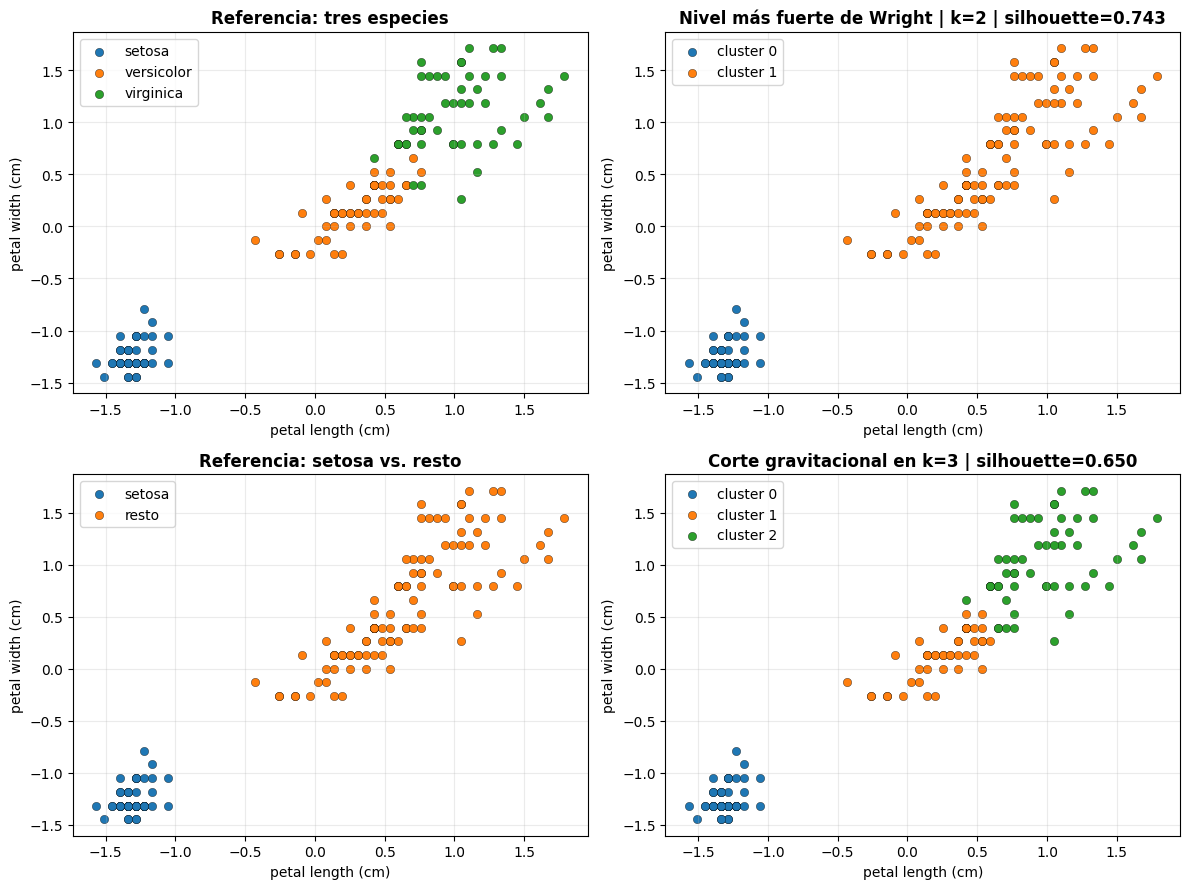

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for k, name in enumerate(species_names):
    mask = y3 == k
    axes[0, 0].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=name
    )
axes[0, 0].set_title("Referencia: tres especies", fontweight="bold")
axes[0, 0].set_xlabel(feature_cols[0])
axes[0, 0].set_ylabel(feature_cols[1])
axes[0, 0].legend()

for cid in np.unique(strong_labels):
    mask = strong_labels == cid
    axes[0, 1].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=f"cluster {cid}"
    )
axes[0, 1].set_title(
    f"Nivel más fuerte de Wright | k={strong_k} | silhouette={strong_silhouette:.3f}",
    fontweight="bold"
)
axes[0, 1].set_xlabel(feature_cols[0])
axes[0, 1].set_ylabel(feature_cols[1])
axes[0, 1].legend()

for label in ["setosa", "resto"]:
    mask = labels_bin == label
    axes[1, 0].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=label
    )
axes[1, 0].set_title("Referencia: setosa vs. resto", fontweight="bold")
axes[1, 0].set_xlabel(feature_cols[0])
axes[1, 0].set_ylabel(feature_cols[1])
axes[1, 0].legend()

for cid in np.unique(labels_k3):
    mask = labels_k3 == cid
    axes[1, 1].scatter(
        X[:, 0][mask], X[:, 1][mask],
        s=36, edgecolors="k", linewidths=0.25, label=f"cluster {cid}"
    )
axes[1, 1].set_title(
    f"Corte gravitacional en k=3 | silhouette={sil_k3:.3f}",
    fontweight="bold"
)
axes[1, 1].set_xlabel(feature_cols[0])
axes[1, 1].set_ylabel(feature_cols[1])
axes[1, 1].legend()

plt.tight_layout()
plt.show()



## 6. Vida temporal de los niveles \(k\)

Esta gráfica resume el criterio interpretativo más cercano al paper. Cada barra representa cuánto tiempo permaneció el sistema con un número fijo de partículas activas.

- una barra alta sugiere una partición estable;
- una barra baja indica un nivel transitorio;
- si \(k=2\) domina claramente, eso favorece una lectura binaria fuerte;
- si \(k=3\) también retiene una vida apreciable, entonces la referencia de tres especies sigue siendo visible dentro de la jerarquía.


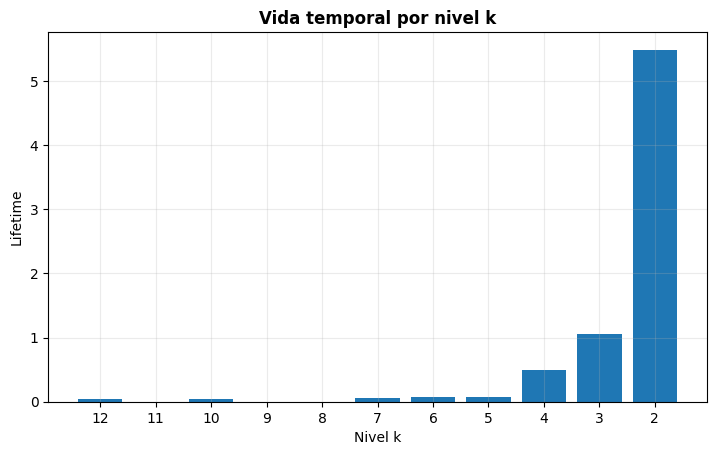

,k,start,end,lifetime,partition
138,12,0.1523,0.1997,0.0474,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
139,11,0.1997,0.1997,0.0000,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
140,10,0.1997,0.2497,0.0500,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
141,9,0.2497,0.2497,0.0000,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
142,8,0.2497,0.2497,0.0000,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
143,7,0.2497,0.3005,0.0507,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
144,6,0.3005,0.3743,0.0738,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
145,5,0.3743,0.4547,0.0804,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
146,4,0.4547,0.9468,0.4921,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."
147,3,0.9468,2.0060,1.0592,"[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13..."


In [9]:

level_plot = (
    classic.level_intervals_[classic.level_intervals_["k"] <= 12]
    .sort_values("k", ascending=False)
    .copy()
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(level_plot["k"].astype(str), level_plot["lifetime"])
ax.set_title("Vida temporal por nivel k", fontweight="bold")
ax.set_xlabel("Nivel k")
ax.set_ylabel("Lifetime")
plt.show()

level_plot.head(12).round(4)



## 7. Dendrograma como representación del *tree plot*

Wright utiliza un *tree plot* para mostrar la jerarquía y el tiempo de las fusiones. El dendrograma siguiente cumple la misma función descriptiva:

- cada unión corresponde a una fusión observada en la simulación;
- la altura representa el tiempo de esa unión;
- los grandes saltos verticales sugieren fusiones entre estructuras ya consolidadas.

Como el conjunto tiene 150 observaciones, una representación completa resulta visualmente densa. Por eso se usa una versión truncada.


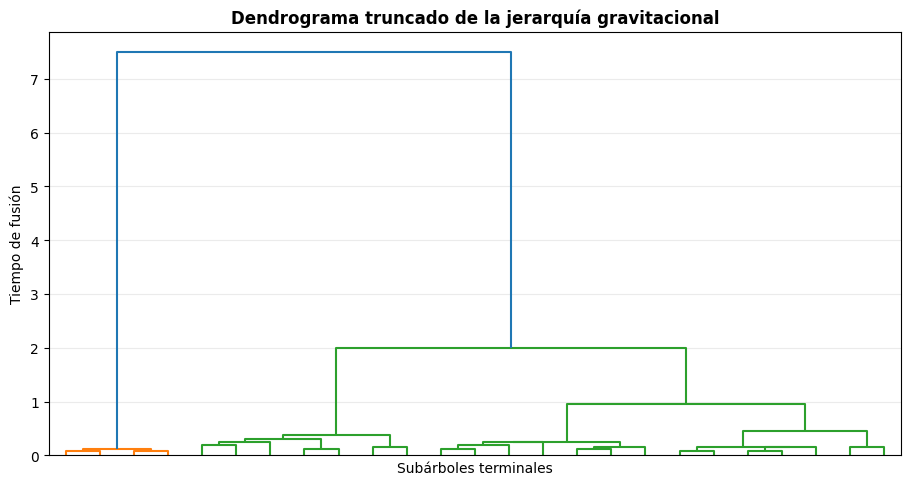

In [10]:

fig, ax = plt.subplots(figsize=(11, 5.5))
dendrogram(
    classic.linkage_matrix_,
    truncate_mode="lastp",
    p=25,
    no_labels=True,
    ax=ax,
)
ax.set_title("Dendrograma truncado de la jerarquía gravitacional", fontweight="bold")
ax.set_xlabel("Subárboles terminales")
ax.set_ylabel("Tiempo de fusión")
plt.show()



## 8. Conclusiones

1. La lectura más fiel al paper sigue siendo temporal: el experimento debe interpretarse primero por la **vida de los niveles \(k\)** y no por una métrica externa aislada.

2. En esta proyección de Iris, la jerarquía gravitacional permite observar tanto una estructura dominante de gran escala como el comportamiento específico del **corte en \(k=3\)**.

3. La comparación con la referencia de las **tres especies** muestra hasta qué punto la jerarquía recupera la taxonomía botánica original. La comparación con **setosa vs. resto** permite ver si la separación más fuerte del sistema coincide con el aislamiento de *setosa*.

4. La **silhouette** no pertenece al paper de Wright, pero sirve aquí como apoyo geométrico para comparar la partición dominante y el corte en \(k=3\).

5. El **dendrograma** sintetiza la información temporal de las fusiones y funciona como complemento visual moderno del *tree plot* descrito por Wright.
